# 06 - Model comparison (test set)

Every earlier notebook scored its model on the **same held-out test split** and
saved `models/predictions_<name>_test.csv`. This notebook reads those files back
and puts every model on one axis: a shared precision-recall curve and a ranked
results table for the README.

It **only reads** - no training, no threshold tuning, and nothing is appended to
`reports/experiments.csv`. That log is already complete; re-running an earlier
notebook would re-log its rows (the file is append-only), so consolidation lives
here in its own read-only notebook instead.

Models are ranked by **test** average precision, not validation. Validation AP is optimistic wherever early stopping or Optuna tuning selected against it, so the honest ranking is the one on data no model has seen - including whether the tuned LightGBM actually improved on its own default.

In [2]:
import sys
from pathlib import Path

# Make `src` importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import config, evaluation

config.set_seed()
config.ensure_dirs()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

## Test-set PR curves - all models on identical rows

Each notebook wrote `models/predictions_<name>_test.csv` on the **same** held-out test split, so every curve is scored on identical rows and is directly comparable. Precision-recall is the axis that matters at a ~5% positive rate: it shows how well each model ranks the rare fraud class, where ROC and accuracy look flatteringly similar. The dashed grey line is the random baseline (test prevalence); each legend entry carries the model's AP, and the summary underneath repeats AP and ROC-AUC.

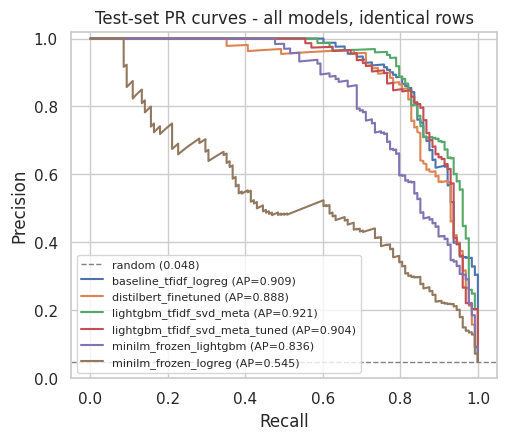

                        model  average_precision  roc_auc
      lightgbm_tfidf_svd_meta             0.9211   0.9918
        baseline_tfidf_logreg             0.9095   0.9912
lightgbm_tfidf_svd_meta_tuned             0.9037   0.9883
         distilbert_finetuned             0.8877   0.9847
       minilm_frozen_lightgbm             0.8360   0.9798
         minilm_frozen_logreg             0.5454   0.9466


In [4]:
LABEL_MAP = {"distilbert": "distilbert_finetuned"}

ax = None
summary = []
for path in sorted(config.MODELS_DIR.glob("predictions_*_test.csv")):
    name = path.stem.replace("predictions_", "").replace("_test", "")
    name = LABEL_MAP.get(name, name)
    frame = pd.read_csv(path)
    ax = evaluation.plot_pr_curve(frame["y_true"], frame["y_proba"], label=name, ax=ax)
    metrics = evaluation.evaluate_predictions(frame["y_true"], frame["y_proba"])
    summary.append({"model": name,
                    "average_precision": metrics["average_precision"],
                    "roc_auc": metrics["roc_auc"]})
ax.set_title("Test-set PR curves - all models, identical rows")
plt.show()

print(pd.DataFrame(summary)
      .sort_values("average_precision", ascending=False)
      .round(4).to_string(index=False))

## Results table (test rows, ranked by AP)

The same numbers, straight from `reports/experiments.csv`.
`evaluation.load_experiments()` returns validation rows by design (train AP is 1.0 and would flatter the ranking), so here we read the raw log and keep the **test** rows - the honest ranking on unseen data. The `threshold` column is each model's own F2-tuned operating point, frozen on validation and applied unchanged to test, so f1/precision/recall are comparable across rows.

In [5]:
# Test rows ranked by the primary metric (AP). load_experiments() returns val rows
# by design (train AP=1.0 would flatter the ranking)
log = pd.read_csv(config.EXPERIMENTS_CSV)
test_rows = log[log["split"] == "test"].sort_values("average_precision", ascending=False)
cols = ["model", "average_precision", "roc_auc", "f1", "precision", "recall", "threshold"]
print(test_rows[cols].round(4).to_string(index=False))

                        model  average_precision  roc_auc     f1  precision  recall  threshold
      lightgbm_tfidf_svd_meta             0.9211   0.9918 0.7904     0.7055  0.8984     0.0948
        baseline_tfidf_logreg             0.9095   0.9912 0.7774     0.7097  0.8594     0.4481
lightgbm_tfidf_svd_meta_tuned             0.9037   0.9883 0.7872     0.7208  0.8672     0.1159
         distilbert_finetuned             0.8877   0.9847 0.8154     0.8030  0.8281     0.0208
       minilm_frozen_lightgbm             0.8360   0.9798 0.6842     0.5909  0.8125     0.0048
         minilm_frozen_logreg             0.5454   0.9466 0.5404     0.4485  0.6797     0.7342


## Conclusions

**No text-first model beats bag-of-words on this dataset.** The tabular LightGBM
(TF-IDF/SVD + metadata) tops the table at test AP 0.921, with the plain TF-IDF -> LogReg baseline just behind at 0.909. Fine-tuned DistilBERT (0.888) and frozen MiniLM (0.836 with a LightGBM head, 0.545 with LogReg) trail both. Explicit lexical cues - dollar amounts, `data entry`, a missing company profile - carry the signal here, and dense semantic representations do not recover it, whether frozen and mean-pooled (MiniLM) or fine-tuned end-to-end (DistilBERT).

**Tuning did not beat the default.** Optuna (40 trials) drove the tuned LightGBM to val AP 0.930 but only test AP 0.904 - below its own untuned 0.921. The sweep maximized validation AP, which did not transfer to held-out data: a val-overfit, not an improvement. The honest read is that LightGBM's defaults were already near the ceiling for this feature set, and a deliberate sweep confirmed it rather than overturning it.

**AP earns its place as the primary metric.** ROC-AUC clusters in a narrow 0.947-0.992 band across every model, while AP spreads from 0.545 to 0.921 - at a ~5% positive rate, ROC and accuracy look uniformly strong and hide the ranking that matters. The same trap appears per-threshold: DistilBERT posts the best F1 (0.815) yet ranks 4th on AP, because F1 is a single operating point while AP integrates over all of them.